# **Classification**

In [1]:
import pandas as pd
filtered = pd.read_csv('/content/drive/MyDrive/datascience/Mini Projects/EcoType: Forest Cover Classification/filtered_data.csv')
filtered.head()

,Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Aspect,Hillshade_3pm,Hillshade_Noon,Wilderness_Area_1,Hillshade_9am,Slope,Wilderness_Area_4,Wilderness_Area_3,Soil_Type_12,Soil_Type_23,Cover_Type_Encoded
0,-1.422686,-1.661258,1.835567,0.258124,-0.915049,-0.765024,0.264532,0.451589,1,0.152380,-1.756890,0,0,0,0,0
1,-1.452980,-1.732357,1.804918,0.024593,-1.217221,-0.687865,0.363490,0.649543,1,0.101360,-2.084479,0,0,0,0,0
2,-0.372506,-0.079292,1.745890,0.305943,0.930837,0.232573,-0.164286,0.847497,1,0.815649,-0.364570,0,0,1,0,4
3,-0.468436,-0.132617,1.796972,0.179560,2.181810,0.366744,-0.593104,0.847497,1,1.019732,1.034132,0,0,0,0,4
4,-1.427735,-1.731765,1.774836,-0.317796,-0.959961,-0.863856,0.330504,0.583558,1,0.101360,-2.084479,0,0,0,0,0


In [2]:
filtered.describe()

,Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Aspect,Hillshade_3pm,Hillshade_Noon,Wilderness_Area_1,Hillshade_9am,Slope,Wilderness_Area_4,Wilderness_Area_3,Soil_Type_12,Soil_Type_23,Cover_Type_Encoded
count,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,145890.000000,1.458900e+05,1.458900e+05,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,-8.104347e-17,-3.272909e-17,-8.727758e-17,1.879975e-17,3.117056e-17,7.597825e-18,1.761137e-16,8.603076e-16,0.921016,-3.896320e-16,-4.246989e-17,0.032045,0.043519,0.199767,0.069573,4.268312
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,0.269715,1.000003e+00,1.000003e+00,0.176119,0.204023,0.399826,0.254427,1.157435
min,-2.606664e+00,-1.963431e+00,-1.728247e+00,-2.178204e+00,-4.710900e+00,-2.429973e+00,-2.506292e+00,-2.583703e+00,0.000000,-2.475184e+00,-2.998353e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-6.602954e-01,-8.684974e-01,-8.155840e-01,-7.307649e-01,-6.634273e-01,-7.182124e-01,-6.260901e-01,-6.041646e-01,1.000000,-5.619089e-01,-7.604614e-01,0.000000,0.000000,0.000000,0.000000,4.000000
50%,1.576336e-01,6.290679e-02,-1.884117e-01,2.459282e-02,-1.801091e-01,-5.693109e-02,6.439382e-04,5.568144e-02,1.000000,2.034011e-01,-8.979499e-03,0.000000,0.000000,0.000000,0.000000,4.000000
75%,6.372833e-01,8.053047e-01,8.133612e-01,7.163150e-01,5.749834e-01,8.192963e-01,6.273780e-01,7.155275e-01,1.000000,7.136077e-01,6.175810e-01,0.000000,0.000000,0.000000,0.000000,4.000000
max,2.583652e+00,2.253366e+00,2.342981e+00,2.027918e+00,2.181810e+00,1.623157e+00,2.507580e+00,1.903250e+00,1.000000,1.836062e+00,2.106662e+00,1.000000,1.000000,1.000000,1.000000,6.000000


# **Checking if the target classes are balanced**

In [3]:
filtered['Cover_Type_Encoded'].value_counts()

,count
Cover_Type_Encoded,
4,103071
6,31110
0,3069
3,2160
5,2160
2,2160
1,2160


# **Handling class imbalance**

In [4]:
# Identify categorical columns for SMOTENC
filtered.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [5]:
from imblearn.over_sampling import SMOTE

# Define features (X) and target (y)
X = filtered.drop('Cover_Type_Encoded', axis=1)
y = filtered['Cover_Type_Encoded']


# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Convert to DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['Cover_Type_Encoded'] = y_resampled

# Verify the new class distribution
df_resampled['Cover_Type_Encoded'].value_counts()


,count
Cover_Type_Encoded,
0,103071
4,103071
6,103071
3,103071
5,103071
2,103071
1,103071


In [6]:
import warnings
import numpy as np
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

In [7]:
df_resampled.columns

Index(['Elevation', 'Horizontal_Distance_To_Roadways',
       'Horizontal_Distance_To_Fire_Points',
       'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
       'Aspect', 'Hillshade_3pm', 'Hillshade_Noon', 'Wilderness_Area_1',
       'Hillshade_9am', 'Slope', 'Wilderness_Area_4', 'Wilderness_Area_3',
       'Soil_Type_12', 'Soil_Type_23', 'Cover_Type_Encoded'],
      dtype='object')

In [8]:
# Splitting data ('loan_status' is the target variable)
X = df_resampled.drop(columns=['Cover_Type_Encoded'])
y = df_resampled['Cover_Type_Encoded']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# Define models to test
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost Classifier": XGBClassifier(n_estimators= 200,use_label_encoder=False, eval_metric='logloss')
}

# Loop through models
for name, model in models.items():
    pipeline = Pipeline([
        ('classifier', model)
    ])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print(f"{name}: Accuracy = {accuracy:.4f}")


Logistic Regression: Accuracy = 0.7320
Decision Tree: Accuracy = 0.9806
K-Nearest Neighbors: Accuracy = 0.9781
Random Forest: Accuracy = 0.9915
XGBoost Classifier: Accuracy = 0.9837


# **Cross Validation**

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
# Define number of folds for Stratified Cross-Validation
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store results
model_results = {}

# Loop through models and apply StratifiedCV
for name, model in models.items():
    pipeline = Pipeline([
        ('classifier', model)
    ])

    # Perform Stratified Cross-Validation
    scores = cross_val_score(pipeline, X, y, cv=stratified_kfold, scoring='accuracy')

    # Store mean accuracy
    model_results[name] = scores.mean()
    print(f"{name}: Mean Accuracy = {scores.mean():.4f}")

Logistic Regression: Mean Accuracy = 0.7307
Decision Tree: Mean Accuracy = 0.9799
K-Nearest Neighbors: Mean Accuracy = 0.9776
Random Forest: Mean Accuracy = 0.9912
XGBoost Classifier: Mean Accuracy = 0.9834


# **📌 Hyperparameter Tuning for Random Forest using RandomizedSearchCV**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

X = df_resampled.drop(columns=['Cover_Type_Encoded'])
y = df_resampled['Cover_Type_Encoded']

# Hyperparameter grid for XGBoost
rf_param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [10,20,None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt','log2'],
    'classifier__max_leaf_nodes': [20, 50, 100 ,None]
    }

# RandomForest Pipeline
rf_pipeline = Pipeline([
    ('classifier',  RandomForestClassifier(random_state=42))
])

rf = RandomForestClassifier(random_state=42)

# Perform GridSearchCV for RandomForest
rf_random = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X, y)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__max_depth': [10, 20, None],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2'],
                                        'classifier__max_leaf_nodes': [20, 50,
                                                                       100,
                                                                       None],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [50, 100,
                                                                     150]},
                   random_state=42, verbose=2)

In [ ]:
print("Best parameters for Random Forest:\n", rf_random.best_params_)
print()
print("Best Random Forest Accuracy (Cross-Validation):", rf_random.best_score_)

# If you want to see the best model object itself
best_rf_model = rf_random.best_estimator_

Best parameters for Random Forest:
 {'classifier__n_estimators': 150, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_leaf_nodes': None, 'classifier__max_features': 'log2', 'classifier__max_depth': None}

Best Random Forest Accuracy (Cross-Validation): 0.927053057739672


In [ ]:
# 1. Best model from the pipeline
best_rf = rf_random.best_estimator_

# 2. Train Accuracy (Accuracy on the data the model saw)
train_acc = best_rf.score(X_train, y_train)

# 3. Test Accuracy (Accuracy on completely new/held-out data)
# Note: Ensure you have a separate X_test and y_test from before SMOTE
test_acc = best_rf.score(X_test, y_test)

print(f"Random Forest Train Accuracy: {train_acc:.4f}")
print(f"Random Forest Test Accuracy:  {test_acc:.4f}")
print(f"Cross-Val Score (best_score_): {rf_random.best_score_:.4f}")


Random Forest Train Accuracy: 0.9991
Random Forest Test Accuracy:  0.9992
Cross-Val Score (best_score_): 0.9271


Random Forest Weighted F1 Score: 0.9992

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20729
           1       1.00      1.00      1.00     20625
           2       1.00      1.00      1.00     20470
           3       1.00      1.00      1.00     20615
           4       1.00      1.00      1.00     20672
           5       1.00      1.00      1.00     20450
           6       1.00      1.00      1.00     20739

    accuracy                           1.00    144300
   macro avg       1.00      1.00      1.00    144300
weighted avg       1.00      1.00      1.00    144300



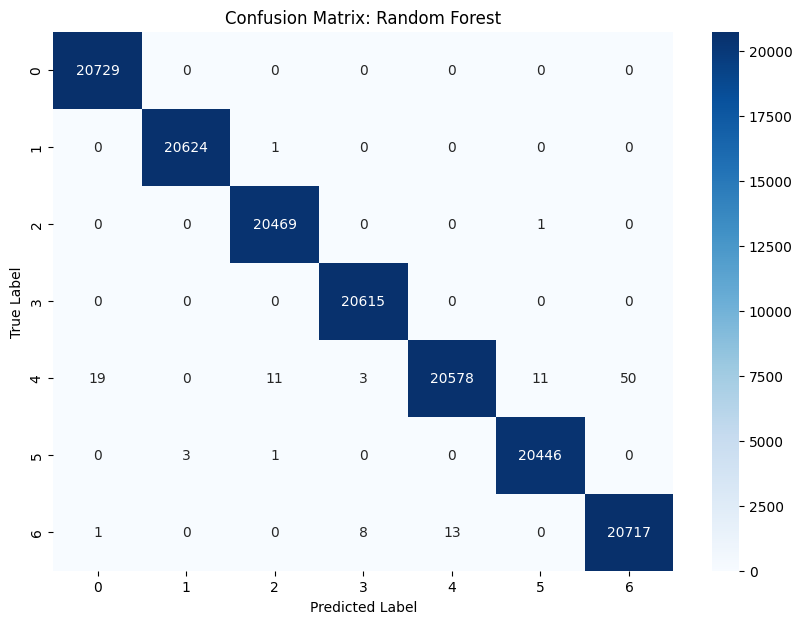

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get predictions
y_pred = best_rf.predict(X_test)

# 2. Calculate F1 Score (use 'weighted' or 'macro' for multi-class)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Random Forest Weighted F1 Score: {f1:.4f}")

# 3. Generate Classification Report (includes F1 for each class)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Generate and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Random Forest')
plt.show()


# **Balanced Training Workflow**

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
X = filtered.drop(columns=['Cover_Type_Encoded'])
y = filtered['Cover_Type_Encoded']
# 1. Split ORIGINAL data FIRST (before any resampling)
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Apply SMOTE ONLY to the Training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_raw, y_train_raw)

# 3. Now run your RandomizedSearchCV using X_train_resampled and y_train_resampled
rf_random.fit(X_train_resampled, y_train_resampled)

# 4. Evaluate on the X_test (which the model has NEVER seen in any form)
y_pred = rf_random.best_estimator_.predict(X_test)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
y_pred = rf_random.best_estimator_.predict(X_test)
print(f"REAL Weighted F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\nREAL Classification Report:")
print(classification_report(y_test, y_pred))

REAL Weighted F1 Score: 0.9468

REAL Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       580
           1       0.90      0.95      0.93       423
           2       0.82      0.80      0.81       440
           3       0.85      0.98      0.91       405
           4       0.98      0.96      0.97     20709
           5       0.77      0.83      0.80       402
           6       0.90      0.91      0.90      6219

    accuracy                           0.95     29178
   macro avg       0.86      0.90      0.88     29178
weighted avg       0.95      0.95      0.95     29178



In [ ]:
# 1. Best model from the pipeline
best_rf = rf_random.best_estimator_

# 2. Train Accuracy (Accuracy on the data the model saw)
train_acc = best_rf.score(X_train_resampled, y_train_resampled)

# 3. Test Accuracy (Accuracy on completely new/held-out data)
# Note: Ensure you have a separate X_test and y_test from before SMOTE
test_acc = best_rf.score(X_test, y_test)

print(f"Random Forest Train Accuracy: {train_acc:.4f}")
print(f"Random Forest Test Accuracy:  {test_acc:.4f}")
print(f"Cross-Val Score (best_score_): {rf_random.best_score_:.4f}")

Random Forest Train Accuracy: 0.9991
Random Forest Test Accuracy:  0.9465
Cross-Val Score (best_score_): 0.9880


In [ ]:
import pickle

# Save your final, reliable model
with open('final_rf_model_v1.pkl', 'wb') as file:
    pickle.dump(best_rf, file)

print("Final model saved successfully!")

Final model saved successfully!
